# **XGBoost for Regression Problem**

### 1. Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

### 2. Creating a Regression Dataset
We will use `make_regression` from scikit-learn to generate a synthetic dataset.

In [6]:
X, y = make_regression(n_samples=1000, n_features=20, n_informative=10, noise=0.1, random_state=42)


df_X = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 21)])
df_y = pd.Series(y, name='Target')

df_X.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20
0,0.225842,1.551378,-0.107347,0.859695,-0.942963,-1.096625,-1.197167,-1.733767,-0.950042,1.274060,1.672990,1.477373,0.335126,-0.621135,-1.525106,1.011097,1.478184,-1.351547,0.364602,0.133166
1,0.110836,-1.454615,0.263888,-1.654510,0.818549,0.482849,0.358334,-0.061366,0.327626,1.270846,-2.128649,-0.546838,2.679629,-1.851587,0.872090,-0.987858,1.744496,-1.426464,-0.604514,-0.166242
2,0.458600,-0.081280,-0.698474,0.737528,0.860085,0.275249,0.333945,-1.076817,0.947821,-0.181406,-0.379908,0.379610,1.508083,0.555380,-1.383018,-0.836187,0.606730,0.908223,0.511415,-2.093178
3,-1.795643,-0.453414,-0.423760,0.155325,0.487775,0.398147,0.732829,2.042178,0.733548,1.598322,-1.274232,-0.734233,0.076609,1.048483,0.008784,-0.141530,-2.104750,-0.330090,-0.511764,-0.237683
4,-1.180626,0.339530,0.328010,-0.224555,0.963951,-1.058450,0.941256,0.968745,-0.002686,0.042907,-0.589144,-1.049914,-1.078364,-0.494912,-0.518436,0.269235,-0.668149,-1.044086,0.482665,-0.579855


### 3. Splitting the Dataset
Split the data into training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (800, 20)
Testing set shape: (200, 20)


### 4. Training the XGBoost Regressor
We initialize and train the `XGBRegressor`.

In [13]:
# Initialize XGBoost Regressor
xg_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5, 
    learning_rate=0.1,
    objective='reg:squarederror', 
    colsample_bytree=0.3, 
    alpha=10)

# Fit the model to the training data
xg_reg.fit(X_train, y_train)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, ...)

# XGBoost Regressor: A Simple Guide to Hyperparameters

Training an XGBoost model is like tuning a high-performance sports car. If you leave everything on the default settings, it will probably run okay. But if you know what the buttons and dials do, you can make it significantly faster and absolutely precise.

Here is a breakdown of the most important `XGBRegressor` hyperparameters, what they mean, and how to use them.


### 1. The Core Engines (General Parameters)

**`n_estimators`** (Default: $100$)
*   **What it is:** The number of trees you want to build in your forest.
*   **Simple Words:** "How many tiny, individual models do you want to create to solve the problem together?"
*   **How to tune:** Higher numbers mean a more robust model, but it will take longer to train and could eventually start memorizing the training data (overfitting). You usually pair this with `early_stopping_rounds`.

**`learning_rate`** (or `eta` in XGBoost docs) (Default: $0.3$)
*   **What it is:** Step size shrinkage used in updates to prevent overfitting.
*   **Simple Words:** "How fast should the model learn?" If set to 1.0, the model learns heavily from every tree. If set to 0.01, it learns very slowly and cautiously.
*   **How to tune:** A smaller learning rate often yields better accuracy, but requires a higher `n_estimators` (more trees) to reach the finish line. $0.05$ to $0.1$ are great starting points.

**`objective`** (Default: `reg:squarederror`)
*   **What it is:** The loss function to be minimized.
*   **Simple Words:** "What exactly are we trying to fix?" For regression (predicting a number like house price or temperature), `reg:squarederror` tells the model to minimize the squared difference between its guess and the actual answer.
    - `reg:squarederror`: (The absolute most common default). This minimizes the squared difference between the prediction and the actual value. It penalizes large errors very heavily.
    - `reg:squaredlogerror`: Similar to above, but it applies a log transformation first. Use this when your target variable has a massive range, and you care more about the percentage error rather than the absolute value.
    - `reg:absoluteerror`: Minimizes the absolute difference (L1 loss). Use this if your dataset has a lot of crazy outliers (extreme values) that you want the model to mostly ignore.
    - `reg:pseudohubererror`: A hybrid between squared error and absolute error. It acts like squared error for small mistakes but like absolute error for massive outliers, giving you the best of both worlds.


### 2. Shaping the Trees (Tree-Specific Parameters)

**`max_depth`** (Default: $6$)
*   **What it is:** The maximum depth of a single decision tree.
*   **Simple Words:** "How complex and deep can a single tree get?" 
*   **How to tune:** Deeper trees can capture very complex patterns (like "If Age > 30 AND Income < 50k AND Car == Red..."), but they are prone to overfitting. A depth of $3$ to $10$ is standard.

**`min_child_weight`** (Default: $1$)
*   **What it is:** Minimum sum of instance weight (hessian) needed in a child (a leaf node). 
*   **Simple Words:** "How many data points (at minimum) must exist in a final bucket before the tree refuses to split anymore?"
*   **How to tune:** Increase this to prevent the model from creating super-specific rules for extreme outliers. A higher value forces the algorithm to be more conservative.

**`gamma`** (Default: $0$)
*   **What it is:** Minimum loss reduction required to make a further partition on a leaf node of the tree.
*   **Simple Words:** "How much better does my prediction have to get before I bother splitting this branch again?"
*   **How to tune:** A value of $0$ means it splits happily if it helps even a tiny bit. Increasing this (like to $1$ or $5$) makes the model stop splitting earlier, reducing overfitting.


### 3. Adding Randomness (Subsampling Parameters)

*Giving the model perfectly clean data every time makes it memorize answers. Adding a bit of chaos (randomness) forces it to actually learn the underlying patterns.*

**`subsample`** (Default: $1.0$)
*   **What it is:** Subsample ratio of the training instances.
*   **Simple Words:** "What percentage of the rows (data points) should I look at when building a single tree?"
*   **How to tune:** If set to $0.8$, each tree only sees a random $80\%$ of the data. This makes the model more robust and prevents overfitting.

**`colsample_bytree`** (Default: $1.0$)
*   **What it is:** Subsample ratio of columns when constructing each tree.
*   **Simple Words:** "What percentage of the columns (features) should I be allowed to use when building a single tree?"
*   **How to tune:** If you have 100 features and set this to $0.8$, each tree can randomly only use 80 of them. This stops the model from relying entirely on just one or two overly strong features.


### 4. Preventing Memorization (Regularization Parameters)

**`alpha`** (or `reg_alpha`) (Default: $0$)
*   **What it is:** L1 regularization term on weights.
*   **Simple Words:** "Lasso Regression." It penalizes the model for using too many features. If a feature isn't very useful, `alpha` will mentally throw it in the trash (push its weight to absolute zero).
*   **How to tune:** Increase this slightly to encourage a simpler model, especially if you have thousands of useless features.

**`lambda`** (or `reg_lambda`) (Default: $1$)
*   **What it is:** L2 regularization term on weights.
*   **Simple Words:** "Ridge Regression." It penalizes the model for relying *too heavily* on any single feature. It won't throw the feature in the trash, but it will shrink its importance so the model isn't overly dependent on it.
*   **How to tune:** Increasing this makes the model more conservative. 


### Summary: The Ultimate "Starting Point"

If you are just starting and want a robust model that won't memorize your training data, try these settings:

```python
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=1000,       # Lots of trees...
    learning_rate=0.05,      # ...but they learn slowly and carefully.
    max_depth=5,             # Keep the trees relatively shallow.
    subsample=0.8,           # Use 80% of rows per tree.
    colsample_bytree=0.8,    # Use 80% of columns per tree.
    objective='reg:squarederror' # We are predicting numbers.
)


### 5. Making Predictions and Evaluating the Model

In [14]:
# Predict on the test set
preds = xg_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE: %f" % (rmse))
print("R2 Score: %f" % (r2))

RMSE: 70.254094
R2 Score: 0.872493


### 6. Visualizing Feature Importance
XGBoost provides a built-in function to plot feature importance.

<Figure size 1000x800 with 0 Axes>

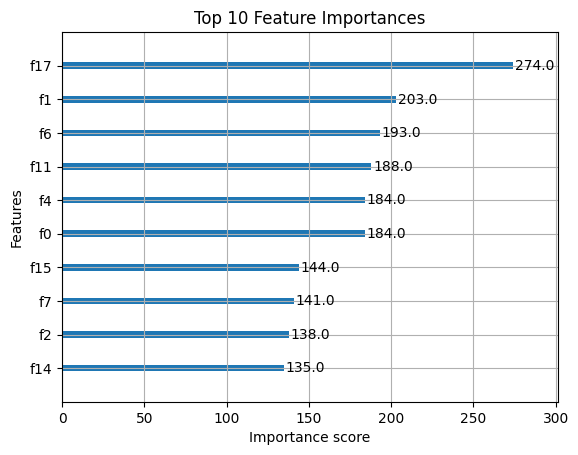

In [15]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xg_reg, max_num_features=10)
plt.title('Top 10 Feature Importances')
plt.show()